# **Data Exploration & Data Cleaning**



## **Uploading Data**

In [1]:
import pandas as pd
file_path = r"C:\Users\BE Smart\OneDrive - Nahda University\Attachments\Desktop\DEPI conent\DEPI project\ALL DATA.xlsx"
all_sheets = pd.read_excel(file_path , sheet_name=None)

In [2]:
all_sheets.keys()

dict_keys(['DimDisease', 'DimChronicDisease', 'DimPatient', 'FactVitals', 'FactLabTests', 'FactEncounter', 'Patient_ChronicDisease'])

In [3]:
disease = all_sheets['DimDisease']
chronic_disease = all_sheets['DimChronicDisease']
patients = all_sheets['DimPatient']
vitals = all_sheets['FactVitals']
lab_tests = all_sheets['FactLabTests']
encounter = all_sheets['FactEncounter']
patient_chronic = all_sheets['Patient_ChronicDisease']

## **Cleaning Patient table**





In [4]:
# Check the number of rows and columns in the dataset
patients.shape

(147852, 10)

In [5]:
# Display all columns name in the dataset
patients.columns

Index(['Patient_ID', 'First_Name', 'Last_Name', 'Gender', 'Birth_Date',
       'Height', 'Weight', 'Marital_Status', 'Nationality', 'Blood_Type'],
      dtype='str')

In [6]:
# Check data types of each column
patients.dtypes

Patient_ID                   str
First_Name                   str
Last_Name                    str
Gender                       str
Birth_Date        datetime64[us]
Height                     int64
Weight                     int64
Marital_Status               str
Nationality                  str
Blood_Type                   str
dtype: object

In [7]:
# Display the first 5 rows of the dataset
patients.head()

,Patient_ID,First_Name,Last_Name,Gender,Birth_Date,Height,Weight,Marital_Status,Nationality,Blood_Type
0,TR477,Davi,Novaes,Male,2023-02-05,77,10,Single,Brazilian,O-
1,TR478,Kane,O'Hehir,Male,1981-09-19,182,94,Single,Irish,B-
2,TR479,Besim,Knecht,Male,1944-06-01,178,107,Single,Swiss,B+
3,TR480,Petro,Korolenko,Male,1988-01-13,180,89,Single,Ukrainian,AB+
4,TR481,Michael,Scott,Male,1998-04-22,184,63,Divorced,Australian,O+


In [8]:
# Generate statistical summary for numerical columns
patients.describe()

,Birth_Date,Height,Weight
count,147852,147852.000000,147852.00000
mean,1958-06-19 15:33:13.571951,159.884912,71.01609
min,1908-01-01 00:00:00,50.000000,3.00000
25%,1931-04-21 00:00:00,154.000000,57.00000
50%,1954-09-08 00:00:00,163.000000,70.00000
75%,1983-08-19 00:00:00,171.000000,84.00000
max,2024-12-28 00:00:00,200.000000,219.00000
std,NaN,19.126693,24.38055


In [9]:
# Get dataset structure including data types and missing values
patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 147852 entries, 0 to 147851
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Patient_ID      147852 non-null  str           
 1   First_Name      147852 non-null  str           
 2   Last_Name       147852 non-null  str           
 3   Gender          147852 non-null  str           
 4   Birth_Date      147852 non-null  datetime64[us]
 5   Height          147852 non-null  int64         
 6   Weight          147852 non-null  int64         
 7   Marital_Status  147852 non-null  str           
 8   Nationality     147852 non-null  str           
 9   Blood_Type      147852 non-null  str           
dtypes: datetime64[us](1), int64(2), str(7)
memory usage: 17.4 MB


In [10]:
# Check number of duplicate rows
patients['Patient_ID'].duplicated().sum()

np.int64(0)

In [11]:
# Check the number of missing values in each column
patients.isnull().sum()

Patient_ID        0
First_Name        0
Last_Name         0
Gender            0
Birth_Date        0
Height            0
Weight            0
Marital_Status    0
Nationality       0
Blood_Type        0
dtype: int64

In [12]:
# Analyze frequency distribution of values in gender column
patients['Gender'].value_counts()

Gender
Female    84300
Male      63552
Name: count, dtype: int64

In [13]:
# Analyze frequency distribution of values in marital status column
patients['Marital_Status'].value_counts()

Marital_Status
Single      46967
Married     33749
Divorced    33622
Widowed     33514
Name: count, dtype: int64

In [14]:
# Get unique values in blood type column
patients['Blood_Type'].unique()

<ArrowStringArray>
['O-', 'B-', 'B+', 'AB+', 'O+', 'A-', 'AB-', 'A+']
Length: 8, dtype: str

In [15]:
# Get unique values in nationality column
patients['Nationality'].unique()

<ArrowStringArray>
[    'Brazilian',         'Irish',         'Swiss',     'Ukrainian',
    'Australian',       'Spanish',        'Polish',      'Canadian',
         'Czech',          'Thai',      'Austrian',    'Portuguese',
     'Hungarian',     'Colombian',       'English',      'Romanian',
       'Turkish',      'Egyptian',       'Swedish',       'Mexican',
        'German',       'Italian',        'Korean',       'Russian',
      'Estonian',      'American',         'Greek',        'Arabic',
      'Filipino',      'Georgian', 'New Zealander',       'Chilean',
        'Indian',      'Japanese',     'Bulgarian',       'Latvian',
    'Indonesian',        'Slovak',      'Croatian',       'Chinese',
   'Argentinian',       'Finnish',    'Lithuanian',        'Danish',
         'Dutch',       'British',     'Norwegian',        'French']
Length: 48, dtype: str

In [16]:
# Remove unnecessary columns from the dataset
patients= patients.drop(columns=['First_Name' , 'Last_Name'])

### ***Age Calculation***

In [17]:
# Calculate patient age from birth date in years
today = pd.to_datetime('today')
patients['Age'] = (today-patients['Birth_Date']).dt.days//365


In [20]:
# Generate statistical summary for numerical columns
patients['Age'].describe()

count    147852.000000
mean         67.581500
std          32.024689
min           1.000000
25%          42.000000
50%          71.000000
75%          95.000000
max         118.000000
Name: Age, dtype: float64

In [18]:
#check outliers in the Age column if the Age<0 and Age>110
patients[patients['Age'] < 0]
patients[patients['Age'] > 110]

,Patient_ID,Gender,Birth_Date,Height,Weight,Marital_Status,Nationality,Blood_Type,Age
66,TR543,Male,1914-02-25,160,66,Divorced,Russian,AB-,112
68,TR545,Female,1914-11-12,161,56,Widowed,Japanese,B-,111
77,TR554,Female,1908-07-28,120,37,Single,Indonesian,O-,118
80,TR557,Male,1915-04-18,170,75,Divorced,Irish,O-,111
91,TR568,Male,1911-02-11,166,54,Married,Chinese,AB-,115
...,...,...,...,...,...,...,...,...,...
147790,TRHIVD267,Female,1910-08-17,156,123,Widowed,Slovak,O+,115
147821,TRHIWI298,Female,1913-06-11,154,60,Single,Swedish,O+,113
147828,TRHIWP305,Female,1910-09-25,124,47,Single,Canadian,O-,115
147834,TRHIWV311,Female,1909-05-07,132,49,Widowed,British,AB-,117


In [19]:
#Display Birth Date and the  created column Age from patient table
patients[['Birth_Date' , 'Age']]

,Birth_Date,Age
0,2023-02-05,3
1,1981-09-19,44
2,1944-06-01,82
3,1988-01-13,38
4,1998-04-22,28
...,...,...
147847,2010-01-21,16
147848,1948-03-22,78
147849,1942-10-24,83
147850,1910-08-25,115


In [22]:
patients['Age_Group'] = pd.cut(patients['Age'],
                            bins=[0, 30, 45, 60, 75, 120],
                            labels=['Young', 'Middle_Age', 'Senior', 'Elderly', 'Very_Elderly'])

### ***BMI Calculation***

In [23]:
# Calculate Body Mass Index (BMI) using weight and height
patients['BMI'] = patients['Weight'] / ((patients['Height'] / 100) ** 2)

In [24]:
# Generate statistical summary for numerical columns
patients['Height'].describe()

count    147852.000000
mean        159.884912
std          19.126693
min          50.000000
25%         154.000000
50%         163.000000
75%         171.000000
max         200.000000
Name: Height, dtype: float64

In [25]:
# Generate statistical summary for numerical columns
patients['Weight'].describe()

count    147852.00000
mean         71.01609
std          24.38055
min           3.00000
25%          57.00000
50%          70.00000
75%          84.00000
max         219.00000
Name: Weight, dtype: float64

In [26]:
patients['Weight_Category'] = pd.cut(patients['Weight'],
                                  bins=[0, 50, 75, 100, 150, 300],
                                  labels=['Very_Light', 'Light', 'Normal', 'Heavy', 'Very_Heavy'])

In [27]:
# Generate statistical summary for numerical columns
patients['BMI'].describe()

count    147852.000000
mean         27.063830
std           7.343908
min           9.349890
25%          22.521508
50%          26.562500
75%          30.461118
max         139.989880
Name: BMI, dtype: float64

In [29]:
patients['BMI'].sort_values().head(10)

83377      9.349890
138258     9.642075
136923     9.684917
62287      9.767712
42515      9.894985
10781      9.908839
115997     9.917355
53731      9.987204
85080     10.007748
44029     10.072953
Name: BMI, dtype: float64

In [30]:
patients['BMI'].sort_values().tail(10)

18218     116.279070
133137    117.631152
72530     118.983234
100589    119.598765
49911     120.092975
21734     122.448980
98919     125.951557
132271    132.653061
5859      132.653061
22649     139.989880
Name: BMI, dtype: float64

In [31]:
patients[(patients['BMI'] < 10) | (patients['BMI'] > 70)].shape

(125, 12)

In [28]:
#Display Weight , Height and the  created column BMI from patient table
patients[['Weight' , 'Height' , 'BMI']]

,Weight,Height,BMI
0,10,77,16.866251
1,94,182,28.378215
2,107,178,33.770989
3,89,180,27.469136
4,63,184,18.608223
...,...,...,...
147847,46,160,17.968750
147848,49,152,21.208449
147849,66,153,28.194284
147850,76,170,26.297578


In [36]:
import matplotlib as plt 
import seaborn as sns

<Axes: xlabel='BMI'>

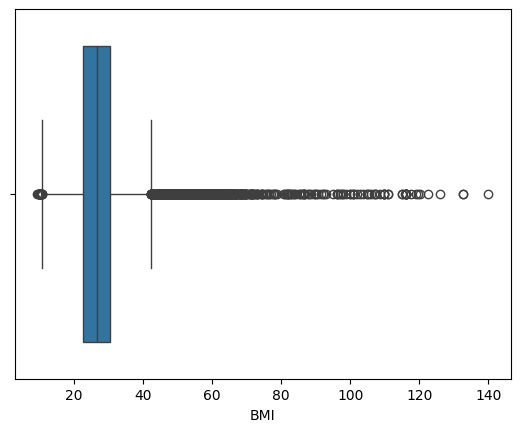

In [39]:
sns.boxplot(x= patients['BMI'])

In [40]:
patients = patients[(patients['BMI'] >= 10) & (patients['BMI'] <= 70)]

<Axes: xlabel='BMI'>

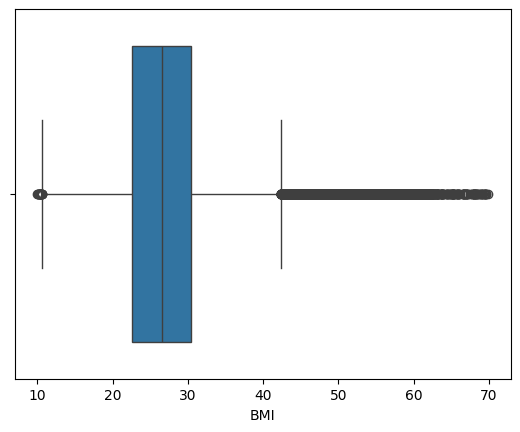

In [41]:
sns.boxplot(x= patients['BMI'])

In [42]:
patients['BMI_Category'] = pd.cut(patients['BMI'],
                               bins=[0, 18.5, 25, 30, 100],
                               labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [43]:
patients['Is_Obese'] = (patients['BMI'] >= 30).astype(int)

In [44]:
#Display patient table
patients

,Patient_ID,Gender,Birth_Date,Height,Weight,Marital_Status,Nationality,Blood_Type,Age,Age_Group,BMI,Weight_Category,BMI_Category,Is_Obese
0,TR477,Male,2023-02-05,77,10,Single,Brazilian,O-,3,Young,16.866251,Very_Light,Underweight,0
1,TR478,Male,1981-09-19,182,94,Single,Irish,B-,44,Middle_Age,28.378215,Normal,Overweight,0
2,TR479,Male,1944-06-01,178,107,Single,Swiss,B+,82,Very_Elderly,33.770989,Heavy,Obese,1
3,TR480,Male,1988-01-13,180,89,Single,Ukrainian,AB+,38,Middle_Age,27.469136,Normal,Overweight,0
4,TR481,Male,1998-04-22,184,63,Divorced,Australian,O+,28,Young,18.608223,Light,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147847,TRHIXI324,Male,2010-01-21,160,46,Single,Norwegian,O+,16,Young,17.968750,Very_Light,Underweight,0
147848,TRHIXJ325,Female,1948-03-22,152,49,Divorced,New Zealander,AB+,78,Very_Elderly,21.208449,Very_Light,Normal,0
147849,TRHIXK326,Female,1942-10-24,153,66,Widowed,Austrian,A+,83,Very_Elderly,28.194284,Light,Overweight,0
147850,TRHIXL327,Male,1910-08-25,170,76,Married,English,B+,115,Very_Elderly,26.297578,Normal,Overweight,0


## **Cleaning Patient Chronic Disease table**




In [45]:
# Check the number of rows and columns in the dataset
patient_chronic.shape

(220278, 2)

In [48]:
# Display all column names in the dataset
patient_chronic.columns

Index(['Patient_ID', 'ChronicDiseaseID'], dtype='str')

In [49]:
# Check data types of each column
patient_chronic.dtypes

Patient_ID            str
ChronicDiseaseID    int64
dtype: object

In [50]:
# Display the first 5 rows of the dataset
patient_chronic.head()

,Patient_ID,ChronicDiseaseID
0,TR477,15
1,TR477,16
2,TR477,17
3,TR478,18
4,TR478,19


In [51]:
# Generate statistical summary for numerical columns
patient_chronic.describe()

,ChronicDiseaseID
count,220278.000000
mean,32.355673
std,12.937059
min,15.000000
25%,21.000000
50%,28.000000
75%,42.000000
max,65.000000


In [52]:
# Get dataset structure including data types and missing values
patient_chronic.info()

<class 'pandas.DataFrame'>
RangeIndex: 220278 entries, 0 to 220277
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Patient_ID        220278 non-null  str  
 1   ChronicDiseaseID  220278 non-null  int64
dtypes: int64(1), str(1)
memory usage: 5.2 MB


In [53]:
# Check number of duplicate rows
patient_chronic.duplicated().sum()

np.int64(0)

In [54]:
# Check the number of missing values in each column
patient_chronic.isnull().sum()

Patient_ID          0
ChronicDiseaseID    0
dtype: int64

In [55]:
patient_chronic['Chronic_Disease_Count'] = (
    patient_chronic.groupby('Patient_ID')['Patient_ID']
    .transform('count'))

## **Cleaning Disease table**

In [57]:
# Check the number of rows and columns in the dataset
disease.shape

(301, 5)

In [58]:
# Display all column names in the dataset
disease.columns

Index(['Disease_ID', 'Admission_Diagnosis', 'Disease_Type', 'Disease_Severity',
       'Medical_Unit'],
      dtype='str')

In [59]:
# Check data types of each column
disease.dtypes

Disease_ID             int64
Admission_Diagnosis      str
Disease_Type             str
Disease_Severity       int64
Medical_Unit             str
dtype: object

In [60]:
# Display the first 5 rows of the dataset
disease.head()

,Disease_ID,Admission_Diagnosis,Disease_Type,Disease_Severity,Medical_Unit
0,1661,Tonsillitis,ENT Diseases,43,Otorhinolaryngology
1,1635,Tooth Decay,Dental Health,20,Dentistry
2,1632,Acute Myeloid Leukemia,Oncology,87,Oncology
3,1452,Kidney Stones,Internal Medicine,46,Nephrology
4,1441,Crohn's Disease,Internal Medicine,75,Gastroenterology


In [61]:
# Generate statistical summary for numerical columns
disease.describe()

,Disease_ID,Disease_Severity
count,301.000000,301.000000
mean,1563.000000,58.671096
std,87.035433,19.634700
min,1413.000000,15.000000
25%,1488.000000,45.000000
50%,1563.000000,60.000000
75%,1638.000000,74.000000
max,1713.000000,97.000000


In [62]:
# Get dataset structure including data types and missing values
disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Disease_ID           301 non-null    int64
 1   Admission_Diagnosis  301 non-null    str  
 2   Disease_Type         301 non-null    str  
 3   Disease_Severity     301 non-null    int64
 4   Medical_Unit         301 non-null    str  
dtypes: int64(2), str(3)
memory usage: 24.6 KB


In [63]:
# Check the number of missing values in each column
disease.isnull().sum()

Disease_ID             0
Admission_Diagnosis    0
Disease_Type           0
Disease_Severity       0
Medical_Unit           0
dtype: int64

In [64]:
# Check number of duplicate rows
disease.duplicated().sum()

np.int64(0)

In [66]:
# Check number of duplicate rows
disease['Disease_ID'].duplicated().sum()

np.int64(0)

In [67]:
# Get unique values in medical unit column
disease['Medical_Unit'].unique()

<ArrowStringArray>
[  'Otorhinolaryngology',             'Dentistry',              'Oncology',
            'Nephrology',      'Gastroenterology',             'Neurology',
          'Rheumatology',            'Cardiology',    'Infectious Disease',
            'Psychiatry',           'Orthopedics',           'Pulmonology',
         'Endocrinology',         'Ophthalmology',            'Hematology',
     'Vascular Medicine', 'Occupational Medicine',               'General',
            'Hepatology',           'Dermatology',            'Pediatrics',
              'Genetics',            'Gynecology',    'Emergency Medicine',
      'General Practice',            'Immunology']
Length: 26, dtype: str

In [68]:
# Get unique values in medical unit column
disease['Disease_Type'].unique()

<ArrowStringArray>
[                 'ENT Diseases',                 'Dental Health',
                      'Oncology',             'Internal Medicine',
                     'Neurology',   'Immunology and Rheumatology',
           'Infectious Diseases',                    'Psychiatry',
  'Orthopedics and Traumatology',         'Occupational Diseases',
                  'Eye Diseases',                    'Hematology',
                    'Pediatrics',              'Genetic Diseases',
                    'Gynecology',                   'Dermatology',
 'Sexually Transmitted Diseases',                       'Unknown']
Length: 18, dtype: str

## **Cleaning Chronic Disease table**

In [69]:
# Check the number of rows and columns in the dataset
chronic_disease.shape

(51, 2)

In [70]:
# Display all column names in the dataset
chronic_disease.columns

Index(['ChronicDiseaseID', 'ChronicDiseaseName'], dtype='str')

In [71]:
# Check data types of each column
chronic_disease.dtypes

ChronicDiseaseID      int64
ChronicDiseaseName      str
dtype: object

In [72]:
# Display the first 5 rows of the dataset
chronic_disease.head()

,ChronicDiseaseID,ChronicDiseaseName
0,15,Sepsis
1,16,Eczema
2,17,Immunodeficiency Disorders
3,18,Arthritis
4,19,Atrial Fibrillation


In [73]:
# Generate statistical summary for numerical columns
chronic_disease.describe()

,ChronicDiseaseID
count,51.000000
mean,40.000000
std,14.866069
min,15.000000
25%,27.500000
50%,40.000000
75%,52.500000
max,65.000000


In [74]:
# Get dataset structure including data types and missing values
chronic_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ChronicDiseaseID    51 non-null     int64
 1   ChronicDiseaseName  51 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [75]:
# Check number of duplicate rows
chronic_disease.duplicated().sum()

np.int64(0)

In [76]:
# Drop unnecessary column from the dataset
chronic_disease= chronic_disease.loc[:, ~chronic_disease.columns.str.contains('^Unnamed')]

In [77]:

# Check the number of missing values in each column
chronic_disease.isnull().sum()

ChronicDiseaseID      0
ChronicDiseaseName    0
dtype: int64

In [78]:
# Check number of duplicate rows
chronic_disease['ChronicDiseaseID'].duplicated().sum()

np.int64(0)

In [79]:
# Get unique values in chronic disease name column
chronic_disease['ChronicDiseaseName'].unique()

<ArrowStringArray>
[                                      'Sepsis',
                                       'Eczema',
                   'Immunodeficiency Disorders',
                                    'Arthritis',
                          'Atrial Fibrillation',
                                   'Depression',
                      'Coronary Artery Disease',
              'Peripheral Artery Disease (PAD)',
                             'Thrombocytopenia',
                              'Crohn's Disease',
                         'Mental Health Issues',
                                       'Asthma',
                          'Parkinson's Disease',
                            'Chronic Back Pain',
                 'Chronic Venous Insufficiency',
                     'Chronic Fatigue Syndrome',
                             'Chronic Tinnitus',
                         'Rheumatoid Arthritis',
                                     'Glaucoma',
                                     'Dementia',
 

## **Cleaning Enocunter table**

In [80]:
# Check the number of rows and columns in the dataset
encounter.shape

(147852, 16)

In [81]:
# Display all column names in the dataset
encounter.columns

Index(['Encounter_ID', 'Patient_ID', 'Disease_ID', 'ResponsibleDoctorID',
       'InsuranceKey', 'RoomKey', 'CheckinDate', 'CheckoutDate',
       'CheckinDateKey', 'CheckoutDateKey', 'Patient_Severity_Score',
       'RadiologyType', 'RadiologyProcedureCount', 'EndoscopyType',
       'EndoscopyProcedureCount', 'CompanionPresent'],
      dtype='str')

In [82]:
# Check data types of each column
encounter.dtypes

Encounter_ID                        int64
Patient_ID                            str
Disease_ID                          int64
ResponsibleDoctorID                 int64
InsuranceKey                        int64
RoomKey                             int64
CheckinDate                datetime64[us]
CheckoutDate               datetime64[us]
CheckinDateKey                      int64
CheckoutDateKey                     int64
Patient_Severity_Score            float64
RadiologyType                         str
RadiologyProcedureCount             int64
EndoscopyType                         str
EndoscopyProcedureCount             int64
CompanionPresent                     bool
dtype: object

In [83]:
# Display the first 5 rows of the dataset
encounter.head()

,Encounter_ID,Patient_ID,Disease_ID,ResponsibleDoctorID,InsuranceKey,RoomKey,CheckinDate,CheckoutDate,CheckinDateKey,CheckoutDateKey,Patient_Severity_Score,RadiologyType,RadiologyProcedureCount,EndoscopyType,EndoscopyProcedureCount,CompanionPresent
0,2156,TR477,1661,896,82,203,2024-03-23 16:52:00,2024-04-28 19:29:00,20240323,20240428,56.2,NaN,0,NaN,0,True
1,2157,TR478,1635,911,83,203,2024-09-14 20:11:00,2024-10-20 12:57:00,20240914,20241020,46.3,NaN,0,NaN,0,True
2,2158,TR479,1632,905,82,203,2024-01-23 11:09:00,2024-03-29 17:00:00,20240123,20240329,63.2,NaN,0,NaN,0,True
3,2159,TR480,1452,843,82,204,2024-08-09 13:36:00,2024-09-13 21:46:00,20240809,20240913,74.9,CT Scan,1,NaN,0,True
4,2160,TR481,1441,836,82,205,2024-11-15 13:00:00,2024-11-30 15:53:00,20241115,20241130,100.0,NaN,0,Capsule Endoscopy,1,True


In [84]:
# Generate statistical summary for numerical columns
encounter.describe()

,Encounter_ID,Disease_ID,ResponsibleDoctorID,InsuranceKey,RoomKey,CheckinDate,CheckoutDate,CheckinDateKey,CheckoutDateKey,Patient_Severity_Score,RadiologyProcedureCount,EndoscopyProcedureCount
count,147852.000000,147852.000000,147852.000000,147852.000000,147852.000000,147852,147852,1.478520e+05,1.478520e+05,147852.000000,147852.000000,147852.000000
mean,76081.500000,1580.916849,862.629001,82.797595,204.167012,2024-07-01 18:23:43.696940,2024-08-07 14:41:06.278771,2.024067e+07,2.024078e+07,67.635682,0.253909,0.041041
min,2156.000000,1413.000000,813.000000,82.000000,203.000000,2024-01-01 06:01:00,2024-01-08 06:18:00,2.024010e+07,2.024011e+07,0.000000,0.000000,0.000000
25%,39118.750000,1480.000000,835.000000,82.000000,203.000000,2024-04-01 06:58:45,2024-05-10 16:49:00,2.024040e+07,2.024051e+07,54.200000,0.000000,0.000000
50%,76081.500000,1601.000000,859.000000,82.000000,204.000000,2024-07-01 16:30:30,2024-08-10 09:53:30,2.024070e+07,2.024081e+07,71.300000,0.000000,0.000000
75%,113044.250000,1684.000000,889.000000,84.000000,205.000000,2024-09-30 21:38:15,2024-11-09 15:33:00,2.024093e+07,2.024111e+07,82.700000,1.000000,0.000000
max,150007.000000,1713.000000,922.000000,84.000000,208.000000,2024-12-30 22:57:00,2024-12-31 22:59:59,2.024123e+07,2.024123e+07,100.000000,1.000000,1.000000
std,42681.340337,102.210687,30.892202,0.870740,1.085490,NaN,NaN,3.445563e+02,3.330309e+02,20.282470,0.435248,0.198386


In [70]:
# Get dataset structure including data types and missing values
encounter.info()

<class 'pandas.DataFrame'>
RangeIndex: 147852 entries, 0 to 147851
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Encounter_ID             147852 non-null  int64         
 1   Patient_ID               147852 non-null  str           
 2   Disease_ID               147852 non-null  int64         
 3   ResponsibleDoctorID      147852 non-null  int64         
 4   InsuranceKey             147852 non-null  int64         
 5   RoomKey                  147852 non-null  int64         
 6   CheckinDate              147852 non-null  datetime64[us]
 7   CheckoutDate             147852 non-null  datetime64[us]
 8   CheckinDateKey           147852 non-null  int64         
 9   CheckoutDateKey          147852 non-null  int64         
 10  Patient_Severity_Score   147852 non-null  float64       
 11  RadiologyType            37541 non-null   str           
 12  RadiologyProcedureCount  14

In [85]:
# Check the number of missing values in each column
encounter.isnull().sum()

Encounter_ID                    0
Patient_ID                      0
Disease_ID                      0
ResponsibleDoctorID             0
InsuranceKey                    0
RoomKey                         0
CheckinDate                     0
CheckoutDate                    0
CheckinDateKey                  0
CheckoutDateKey                 0
Patient_Severity_Score          0
RadiologyType              110311
RadiologyProcedureCount         0
EndoscopyType              141784
EndoscopyProcedureCount         0
CompanionPresent                0
dtype: int64

In [86]:
# Check number of duplicate rows
encounter.duplicated().sum()

np.int64(0)

In [87]:
# Check the number of missing values encounter id column and number of duplicate rows
encounter['Encounter_ID'].isna().sum()
encounter['Encounter_ID'].duplicated().sum()

np.int64(0)

In [88]:
# Replace specific values in Endscopy Type (None → No Endscopy)
encounter['EndoscopyType'] = encounter['EndoscopyType'].replace({None: "No Endoscopy"})
# Replace specific values in Radiology Type (None → No Radiology)
encounter['RadiologyType'] = encounter['RadiologyType'].replace({None: "No Radiology"})

In [89]:
# Analyze frequency distribution of values in endscopy type column
encounter['EndoscopyType'].value_counts()

EndoscopyType
No Endoscopy         141784
Bronchoscopy           2101
Gastroscopy            1941
Colonoscopy             669
Sigmoidoscopy           564
Laryngoscopy            400
Capsule Endoscopy       393
Name: count, dtype: int64

In [90]:
# Analyze frequency distribution of values in radiology type column
encounter['RadiologyType'].value_counts()

RadiologyType
No Radiology          110311
X-Ray                   6554
MRI                     5991
Echocardiography        5495
Chest X-Ray             5479
CT Scan                 4446
Ultrasound              3403
PET Scan                3349
Thyroid Ultrasound      1333
DEXA Scan                542
Bone Scan                489
Mammography              233
Adrenal CT               227
Name: count, dtype: int64

In [91]:
# Check if records with dates later than today (future dates)
encounter[encounter['CheckinDate'] > pd.Timestamp.today()]
encounter[encounter['CheckoutDate'] > pd.Timestamp.today()]

,Encounter_ID,Patient_ID,Disease_ID,ResponsibleDoctorID,InsuranceKey,RoomKey,CheckinDate,CheckoutDate,CheckinDateKey,CheckoutDateKey,Patient_Severity_Score,RadiologyType,RadiologyProcedureCount,EndoscopyType,EndoscopyProcedureCount,CompanionPresent


In [92]:
# check records where checkout date is earlier than check-in date
encounter[encounter['CheckoutDate'] < encounter['CheckinDate']]

,Encounter_ID,Patient_ID,Disease_ID,ResponsibleDoctorID,InsuranceKey,RoomKey,CheckinDate,CheckoutDate,CheckinDateKey,CheckoutDateKey,Patient_Severity_Score,RadiologyType,RadiologyProcedureCount,EndoscopyType,EndoscopyProcedureCount,CompanionPresent


In [93]:
# Calculate length of stay by subtracting check-in date from check-out date
encounter['total_stay_days'] = (encounter['CheckoutDate'] - encounter['CheckinDate']).dt.days

In [94]:
#Display Checkin date , Checkout Date and Total Stay days columns
encounter[['CheckinDate','CheckoutDate','total_stay_days']]

,CheckinDate,CheckoutDate,total_stay_days
0,2024-03-23 16:52:00,2024-04-28 19:29:00,36
1,2024-09-14 20:11:00,2024-10-20 12:57:00,35
2,2024-01-23 11:09:00,2024-03-29 17:00:00,66
3,2024-08-09 13:36:00,2024-09-13 21:46:00,35
4,2024-11-15 13:00:00,2024-11-30 15:53:00,15
...,...,...,...
147847,2024-09-14 16:42:00,2024-10-31 10:25:00,46
147848,2024-11-07 10:17:00,2024-12-31 22:59:59,54
147849,2024-09-24 09:34:00,2024-10-13 11:06:00,19
147850,2024-10-21 12:37:00,2024-12-17 17:32:00,57


In [95]:
# Drop unnecessary column from the dataset
encounter.drop('ResponsibleDoctorID', axis=1, inplace=True)

In [96]:
#Display Encounter Table
encounter

,Encounter_ID,Patient_ID,Disease_ID,InsuranceKey,RoomKey,CheckinDate,CheckoutDate,CheckinDateKey,CheckoutDateKey,Patient_Severity_Score,RadiologyType,RadiologyProcedureCount,EndoscopyType,EndoscopyProcedureCount,CompanionPresent,total_stay_days
0,2156,TR477,1661,82,203,2024-03-23 16:52:00,2024-04-28 19:29:00,20240323,20240428,56.2,No Radiology,0,No Endoscopy,0,True,36
1,2157,TR478,1635,83,203,2024-09-14 20:11:00,2024-10-20 12:57:00,20240914,20241020,46.3,No Radiology,0,No Endoscopy,0,True,35
2,2158,TR479,1632,82,203,2024-01-23 11:09:00,2024-03-29 17:00:00,20240123,20240329,63.2,No Radiology,0,No Endoscopy,0,True,66
3,2159,TR480,1452,82,204,2024-08-09 13:36:00,2024-09-13 21:46:00,20240809,20240913,74.9,CT Scan,1,No Endoscopy,0,True,35
4,2160,TR481,1441,82,205,2024-11-15 13:00:00,2024-11-30 15:53:00,20241115,20241130,100.0,No Radiology,0,Capsule Endoscopy,1,True,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147847,150003,TRHIXI324,1630,82,205,2024-09-14 16:42:00,2024-10-31 10:25:00,20240914,20241031,83.5,MRI,1,No Endoscopy,0,True,46
147848,150004,TRHIXJ325,1706,82,205,2024-11-07 10:17:00,2024-12-31 22:59:59,20241107,20241231,82.6,X-Ray,1,No Endoscopy,0,True,54
147849,150005,TRHIXK326,1487,82,203,2024-09-24 09:34:00,2024-10-13 11:06:00,20240924,20241013,67.3,X-Ray,1,No Endoscopy,0,True,19
147850,150006,TRHIXL327,1583,82,205,2024-10-21 12:37:00,2024-12-17 17:32:00,20241021,20241217,86.3,Bone Scan,1,No Endoscopy,0,True,57


## **Cleaning Vitals table**

In [97]:
# Check the number of rows and columns in the dataset
vitals.shape

(295704, 9)

In [98]:
# Display all column names in the dataset
vitals.columns

Index(['Encounter_ID', 'Patient_ID', 'Phase', 'HeartRate', 'Temperature',
       'SystolicBP', 'DiastolicBP', 'RespRate', 'O2Sat'],
      dtype='str')

In [99]:
# Check data types of each column
vitals.dtypes

Encounter_ID      int64
Patient_ID          str
Phase               str
HeartRate       float64
Temperature     float64
SystolicBP        int64
DiastolicBP       int64
RespRate          int64
O2Sat           float64
dtype: object

In [100]:
# Display the first 5 rows of the dataset
vitals.head()

,Encounter_ID,Patient_ID,Phase,HeartRate,Temperature,SystolicBP,DiastolicBP,RespRate,O2Sat
0,2156,TR477,Admission,106.2,38.6,85,50,33,99.0
1,2156,TR477,Discharge,110.0,37.1,111,68,24,98.0
2,2157,TR478,Admission,89.0,36.1,103,87,12,95.4
3,2157,TR478,Discharge,91.0,36.0,112,88,10,94.8
4,2158,TR479,Admission,98.0,36.3,135,78,13,94.6


In [101]:
# Get dataset structure including data types and missing values
vitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 295704 entries, 0 to 295703
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Encounter_ID  295704 non-null  int64  
 1   Patient_ID    295704 non-null  str    
 2   Phase         295704 non-null  str    
 3   HeartRate     295704 non-null  float64
 4   Temperature   295704 non-null  float64
 5   SystolicBP    295704 non-null  int64  
 6   DiastolicBP   295704 non-null  int64  
 7   RespRate      295704 non-null  int64  
 8   O2Sat         295704 non-null  float64
dtypes: float64(3), int64(4), str(2)
memory usage: 25.3 MB


In [102]:
# Check number of duplicate rows
vitals.duplicated().sum()

np.int64(0)

In [103]:
# Check the number of missing values in each column
vitals.isnull().sum()

Encounter_ID    0
Patient_ID      0
Phase           0
HeartRate       0
Temperature     0
SystolicBP      0
DiastolicBP     0
RespRate        0
O2Sat           0
dtype: int64

In [104]:
# Generate statistical summary for numerical columns
vitals.describe()

,Encounter_ID,HeartRate,Temperature,SystolicBP,DiastolicBP,RespRate,O2Sat
count,295704.000000,295704.000000,295704.000000,295704.000000,295704.000000,295704.000000,295704.000000
mean,76081.500000,85.032508,36.954309,117.588768,75.792593,15.634259,95.131645
std,42681.268168,19.511932,0.878460,11.580728,8.740676,3.448288,3.414942
min,2156.000000,40.000000,35.000000,85.000000,50.000000,10.000000,65.000000
25%,39118.750000,72.000000,36.400000,110.000000,70.000000,13.000000,94.300000
50%,76081.500000,83.000000,36.700000,118.000000,76.000000,15.000000,95.700000
75%,113044.250000,94.000000,37.200000,126.000000,82.000000,17.000000,96.800000
max,150007.000000,173.000000,40.900000,172.000000,117.000000,40.000000,100.000000


In [105]:
vitals['SystolicBP'].describe()
vitals['DiastolicBP'].describe()

count    295704.000000
mean         75.792593
std           8.740676
min          50.000000
25%          70.000000
50%          76.000000
75%          82.000000
max         117.000000
Name: DiastolicBP, dtype: float64

### ***Heart Rate Calculations***

In [106]:
vitals['HeartRate'].describe()

count    295704.000000
mean         85.032508
std          19.511932
min          40.000000
25%          72.000000
50%          83.000000
75%          94.000000
max         173.000000
Name: HeartRate, dtype: float64

In [107]:
vitals['Is_Tachycardia'] = (vitals['HeartRate'] > 100).astype(int)

### ***Tempurature Calculations***

In [108]:
vitals['Temperature'].describe()

count    295704.000000
mean         36.954309
std           0.878460
min          35.000000
25%          36.400000
50%          36.700000
75%          37.200000
max          40.900000
Name: Temperature, dtype: float64

In [109]:
vitals['Has_Fever'] = (vitals['Temperature'] > 38).astype(int)


### ***MAP Calculations***

In [110]:
vitals['MAP'] = (vitals['SystolicBP'] + 2 * vitals['DiastolicBP']) / 3

In [111]:
vitals['MAP'].describe()

count    295704.000000
mean         89.724651
std           8.236450
min          61.666667
25%          85.000000
50%          90.333333
75%          94.666667
max         132.333333
Name: MAP, dtype: float64

In [112]:
vitals

,Encounter_ID,Patient_ID,Phase,HeartRate,Temperature,SystolicBP,DiastolicBP,RespRate,O2Sat,Is_Tachycardia,Has_Fever,MAP
0,2156,TR477,Admission,106.2,38.6,85,50,33,99.0,1,1,61.666667
1,2156,TR477,Discharge,110.0,37.1,111,68,24,98.0,1,0,82.333333
2,2157,TR478,Admission,89.0,36.1,103,87,12,95.4,0,0,92.333333
3,2157,TR478,Discharge,91.0,36.0,112,88,10,94.8,0,0,96.000000
4,2158,TR479,Admission,98.0,36.3,135,78,13,94.6,0,0,97.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
295699,150005,TRHIXK326,Discharge,78.0,36.7,128,68,12,94.1,0,0,88.000000
295700,150006,TRHIXL327,Admission,97.0,37.1,127,81,13,94.5,0,0,96.333333
295701,150006,TRHIXL327,Discharge,96.0,37.0,128,77,13,93.7,0,0,94.000000
295702,150007,TRHIXM328,Admission,89.6,36.0,118,98,14,96.1,0,0,104.666667


## **Cleaning Lab Tests Table**

In [113]:
# Check the number of rows and columns in the dataset
lab_tests.shape

(1048575, 6)

In [114]:
# Display all column names in the dataset
lab_tests.columns

Index(['Encounter_ID', 'Patient_ID', 'Phase', 'LabType', 'TestName',
       'TestValue'],
      dtype='str')

In [115]:
# Check data types of each column
lab_tests.dtypes

Encounter_ID      int64
Patient_ID          str
Phase               str
LabType             str
TestName            str
TestValue       float64
dtype: object

In [116]:
# Display the first 5 rows of the dataset
lab_tests.head()

,Encounter_ID,Patient_ID,Phase,LabType,TestName,TestValue
0,2156,TR477,Admission,CBC,RBC (10^6/Âµl),4.54
1,2156,TR477,Admission,CBC,Hemoglobin (g/dl),13.40
2,2156,TR477,Admission,CBC,Hematocrit (%),40.60
3,2156,TR477,Admission,CBC,MCV (fL),88.00
4,2156,TR477,Admission,CBC,MCH (pg),28.10


In [117]:
# Generate statistical summary for numerical columns
lab_tests.describe()

,Encounter_ID,TestValue
count,1.048575e+06,1.048575e+06
mean,9.645321e+03,4.642337e+01
std,4.324252e+03,5.956083e+01
min,2.156000e+03,0.000000e+00
25%,5.900000e+03,4.000000e+00
50%,9.645000e+03,1.790000e+01
75%,1.339000e+04,8.510000e+01
max,1.713500e+04,8.240000e+02


In [118]:
# Get dataset structure including data types and missing values
lab_tests.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Encounter_ID  1048575 non-null  int64  
 1   Patient_ID    1048575 non-null  str    
 2   Phase         1048575 non-null  str    
 3   LabType       1048575 non-null  str    
 4   TestName      1048575 non-null  str    
 5   TestValue     1048575 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 84.7 MB


In [119]:
# Check number of duplicate rows
lab_tests.duplicated().sum()

np.int64(0)

In [120]:
# Check the number of missing values in each column
lab_tests.isnull().sum()

Encounter_ID    0
Patient_ID      0
Phase           0
LabType         0
TestName        0
TestValue       0
dtype: int64

In [121]:
# Get unique values in lab type column
lab_tests['LabType'].unique()

<ArrowStringArray>
['CBC', 'Chem', 'Lipids', 'CRP']
Length: 4, dtype: str

In [122]:
# Get unique values in test name column
lab_tests['TestName'].unique()

<ArrowStringArray>
[            'RBC (10^6/Âµl)',          'Hemoglobin (g/dl)',
             'Hematocrit (%)',                   'MCV (fL)',
                   'MCH (pg)',                'MCHC (g/dl)',
                    'RDW (%)',       'Platelets (10^3/Âµl)',
             'WBC (10^3/Âµl)', 'Neutrophils_abs (10^3/Âµl)',
 'Lymphocytes_abs (10^3/Âµl)',   'Monocytes_abs (10^3/Âµl)',
 'Eosinophils_abs (10^3/Âµl)',   'Basophils_abs (10^3/Âµl)',
            'Glucose (mg/dl)',                'BUN (mg/dl)',
         'Creatinine (mg/dl)',      'eGFR (ml/min/1.73m^2)',
             'Sodium (mEq/l)',          'Potassium (mEq/l)',
           'Chloride (mEq/l)',       'Total_protein (g/dl)',
             'Albumin (g/dl)',          'Uric_acid (mg/dl)',
                  'ALT (U/l)',                  'AST (U/l)',
                  'ALP (U/l)',                  'GGT (U/l)',
    'Total_bilirubin (mg/dl)',   'TotalCholesterol (mg/dl)',
                'LDL (mg/dl)',                'HDL (mg/dl)',
     

In [123]:
# - Remove unnecessary spaces and Replace inconsistent text values
lab_tests['TestName'] = lab_tests['TestName'].str.strip()
lab_tests['TestName'] = lab_tests['TestName'].str.replace('Âµ', 'µ', regex=False)

In [124]:
# Get unique values in test name column
lab_tests['TestName'].unique()

<ArrowStringArray>
[            'RBC (10^6/µl)',         'Hemoglobin (g/dl)',
            'Hematocrit (%)',                  'MCV (fL)',
                  'MCH (pg)',               'MCHC (g/dl)',
                   'RDW (%)',       'Platelets (10^3/µl)',
             'WBC (10^3/µl)', 'Neutrophils_abs (10^3/µl)',
 'Lymphocytes_abs (10^3/µl)',   'Monocytes_abs (10^3/µl)',
 'Eosinophils_abs (10^3/µl)',   'Basophils_abs (10^3/µl)',
           'Glucose (mg/dl)',               'BUN (mg/dl)',
        'Creatinine (mg/dl)',     'eGFR (ml/min/1.73m^2)',
            'Sodium (mEq/l)',         'Potassium (mEq/l)',
          'Chloride (mEq/l)',      'Total_protein (g/dl)',
            'Albumin (g/dl)',         'Uric_acid (mg/dl)',
                 'ALT (U/l)',                 'AST (U/l)',
                 'ALP (U/l)',                 'GGT (U/l)',
   'Total_bilirubin (mg/dl)',  'TotalCholesterol (mg/dl)',
               'LDL (mg/dl)',               'HDL (mg/dl)',
     'Triglycerides (mg/dl)',        

# **Downloading Clean DataSet**

In [111]:
with pd.ExcelWriter("HealthcareCleaned.xlsx", engine="openpyxl") as writer:
    patients.to_excel(writer, sheet_name="Patients", index=False)
    vitals.to_excel(writer, sheet_name="Vitals", index=False)
    patient_chronic.to_excel(writer, sheet_name="Patient_chronic", index=False)
    lab_tests.to_excel(writer, sheet_name="Lab_tests", index=False)
    disease.to_excel(writer, sheet_name="Disease", index=False)
    encounter.to_excel(writer, sheet_name="Encounter", index=False)
    chronic_disease.to_excel(writer, sheet_name="Chronic", index=False)